# Notebook 04 - Spain 2022 Tactical Analysis (Groups A-D)
### Territory, Buildup, Progression & Chance Creation (Featuring France Baseline)

**Hypotheses tested:** H1 (Sterile possession), H2 (Lack of directness), H3 (Predictable buildup), H4 (Central overload), H6 (xG underperformance)

In [1]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.colors import LinearSegmentedColormap
from mplsoccer import Pitch, VerticalPitch
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs/figures/2022', exist_ok=True)
sys.path.insert(0, os.path.abspath('..'))
from utils.config import OUTPUTS_DATA_DIR

df = pd.read_parquet(os.path.join(OUTPUTS_DATA_DIR, 'master_events_cleaned.parquet'))
spain_22 = df[(df['tournament']=='WC2022') & (df['team']=='Spain')].copy()
france_22 = df[(df['tournament']=='WC2022') & (df['team']=='France')].copy()
opponents_22 = df[(df['tournament']=='WC2022') & (df['team']!='Spain')].copy()

print(f'Spain WC2022 events: {len(spain_22):,}')
print(f'France WC2022 events: {len(france_22):,}')

Spain WC2022 events: 12,322
France WC2022 events: 13,361


---
## GROUP A: Territory & Possession Quality
**Question:** Did Spain control the ball, or control the pitch? (Compared to France)

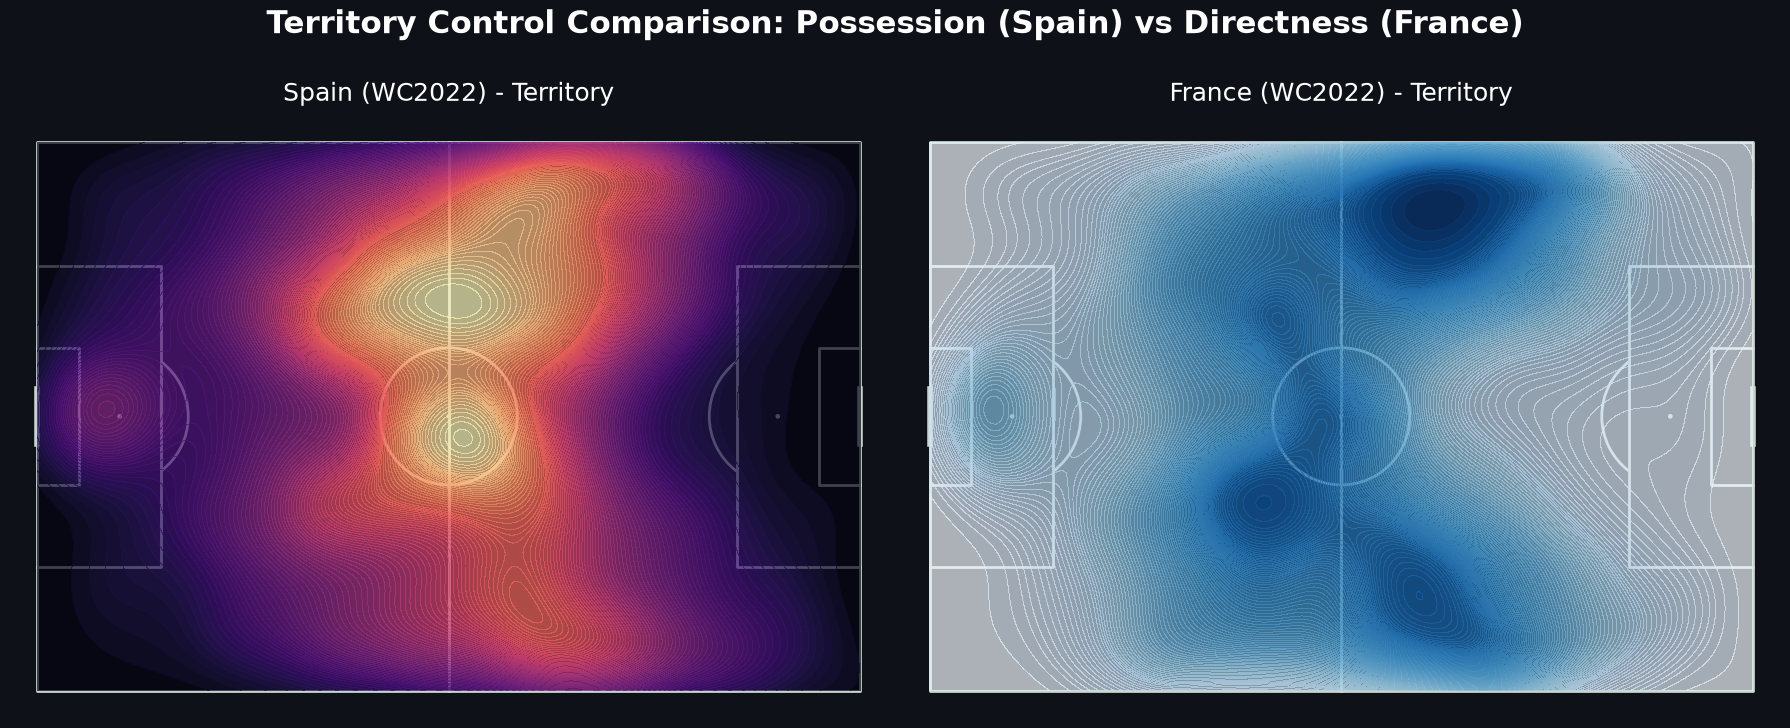

In [2]:
# === VIZ 1: Territory Heatmap (Spain vs France Comparison) ===
spain_touches = spain_22[spain_22['type'].isin(['Pass','Carry','Shot','Ball Recovery','Dribble'])].dropna(subset=['x','y'])
france_touches = france_22[france_22['type'].isin(['Pass','Carry','Shot','Ball Recovery','Dribble'])].dropna(subset=['x','y'])

pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0e1117')

# Spain
pitch.draw(ax=axes[0])
pitch.kdeplot(spain_touches['x'], spain_touches['y'], ax=axes[0], fill=True, levels=100, thresh=0, cut=4, cmap='magma', alpha=0.7, zorder=1)
axes[0].set_title('Spain (WC2022) - Territory', color='white', fontsize=18, pad=10)

# France
pitch.draw(ax=axes[1])
pitch.kdeplot(france_touches['x'], france_touches['y'], ax=axes[1], fill=True, levels=100, thresh=0, cut=4, cmap='Blues', alpha=0.7, zorder=1)
axes[1].set_title('France (WC2022) - Territory', color='white', fontsize=18, pad=10)

fig.suptitle('Territory Control Comparison: Possession (Spain) vs Directness (France)', color='white', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/2022/viz01_territory_comparison.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [3]:
# === Zone-by-zone touch share ===
touch_types = ['Pass','Carry','Shot','Ball Recovery','Dribble','Ball Receipt*']
spain_t = spain_22[spain_22['type'].isin(touch_types)].dropna(subset=['zone_third'])
france_t = france_22[france_22['type'].isin(touch_types)].dropna(subset=['zone_third'])

s_share = spain_t['zone_third'].value_counts(normalize=True)*100
f_share = france_t['zone_third'].value_counts(normalize=True)*100

print('WC2022 - TOUCH DISTRIBUTION BY PITCH THIRD (SPAIN vs FRANCE)')
print('='*60)
for z in ['Defensive Third','Middle Third','Final Third']:
    print(f'  {z:20s}: Spain {s_share.get(z,0):.1f}%  |  France {f_share.get(z,0):.1f}%')

WC2022 - TOUCH DISTRIBUTION BY PITCH THIRD (SPAIN vs FRANCE)
  Defensive Third     : Spain 19.3%  |  France 21.9%
  Middle Third        : Spain 56.3%  |  France 52.2%
  Final Third         : Spain 24.3%  |  France 25.9%


---
## GROUP B: Buildup Structure
**Question:** How did Spain build attacks, and how rigid was the shape?

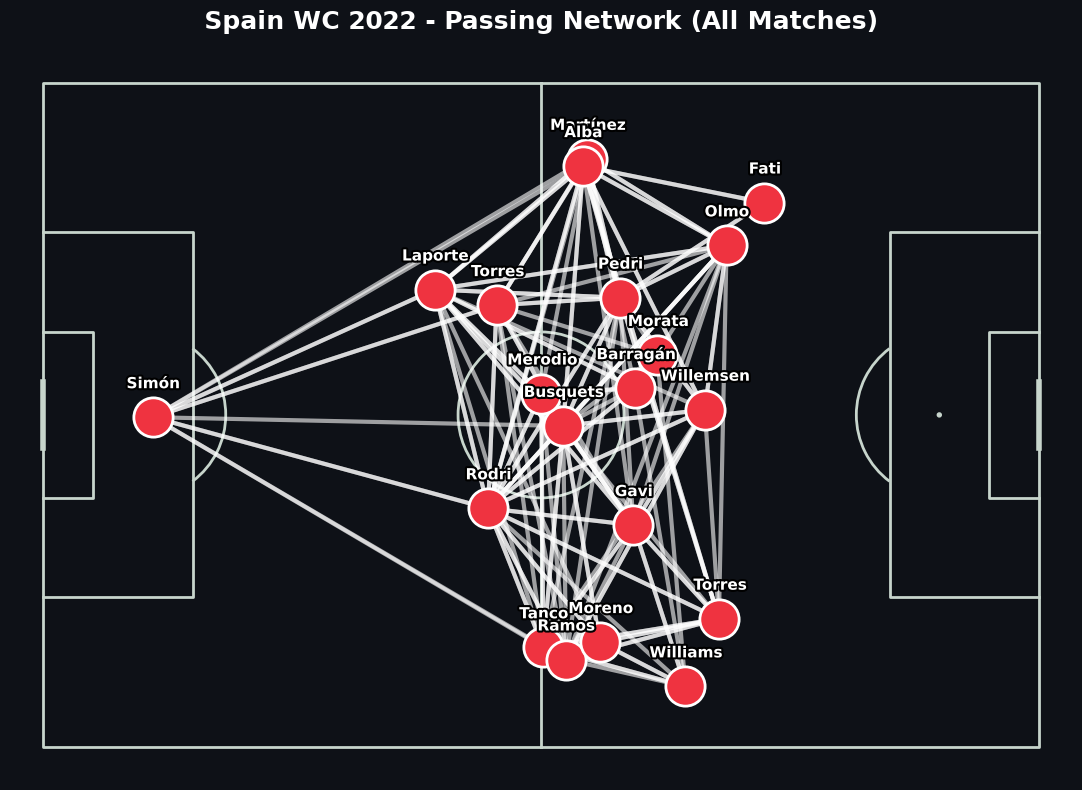

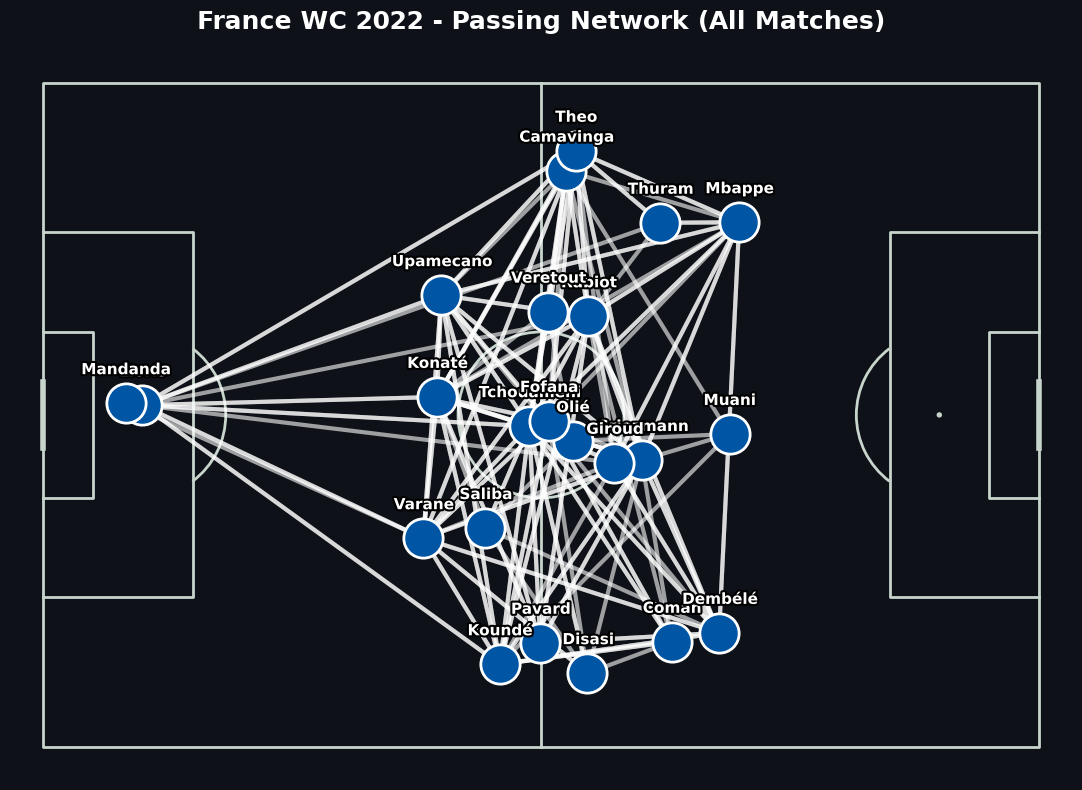

In [4]:
# === VIZ 3: Passing Network (FIXED SCALING) ===
def draw_pass_network(match_df, title, filename, color='#ef3340'):
    passes = match_df[(match_df['type']=='Pass') & (match_df['pass_outcome'].isna())].copy()
    passes = passes.dropna(subset=['common_name','pass_recipient','x','y'])
    
    name_map = match_df[['player','common_name']].dropna().drop_duplicates().set_index('player')['common_name'].to_dict()
    passes['recip'] = passes['pass_recipient'].map(lambda x: name_map.get(x,x))
    
    avg = passes.groupby('common_name').agg(x=('x','mean'), y=('y','mean'), count=('x','count'))
    avg = avg[avg['count']>15]
    
    combos = passes.groupby(['common_name','recip']).size().reset_index(name='n')
    combos = combos[(combos['n']>4) & combos['common_name'].isin(avg.index) & combos['recip'].isin(avg.index)]
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
    fig, ax = pitch.draw(figsize=(12,8))
    fig.set_facecolor('#0e1117')
    
    for _, r in combos.iterrows():
        if r['common_name'] in avg.index and r['recip'] in avg.index:
            # Fixed line width instead of scaling infinitely
            pitch.lines(avg.loc[r['common_name'],'x'], avg.loc[r['common_name'],'y'],
                        avg.loc[r['recip'],'x'], avg.loc[r['recip'],'y'],
                        ax=ax, color='white', lw=3, alpha=0.6, zorder=1)
    
    # Fixed node size instead of scaling infinitely
    pitch.scatter(avg['x'], avg['y'], s=800, color=color,
                  edgecolors='white', lw=2, ax=ax, zorder=2)
    
    for name, r in avg.iterrows():
        # Clean up long names especially for French players
        name_str = str(name)
        label = name_str.split()[-1] if len(name_str.split()) > 1 else name_str
        if 'Mbapp' in name_str or 'Mbapp' in label: label = 'Mbappe'
        elif 'Tchouam' in name_str: label = 'Tchouameni'
        elif 'Griezmann' in name_str: label = 'Griezmann'
        elif 'Hern' in label: label = 'Theo'
        
        # Add slight shadow to text for readability
        ax.annotate(label, (r['x'], r['y']-3.5), color='white', ha='center', fontsize=11, fontweight='bold', zorder=3,
                    path_effects=[path_effects.withStroke(linewidth=3, foreground='black')])
    
    ax.set_title(title, color='white', fontsize=18, fontweight='bold', pad=15)
    plt.savefig(f'../outputs/figures/2022/{filename}', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

draw_pass_network(spain_22, 'Spain WC 2022 - Passing Network (All Matches)', 'viz03_pass_network_all.png', color='#ef3340')

# France Pass Network
france_df = france_22.copy()
# For France, use player name if common_name is missing
france_df['common_name'] = france_df['common_name'].fillna(france_df['player'])
draw_pass_network(france_df, 'France WC 2022 - Passing Network (All Matches)', 'viz03_pass_network_france.png', color='#0055A4')


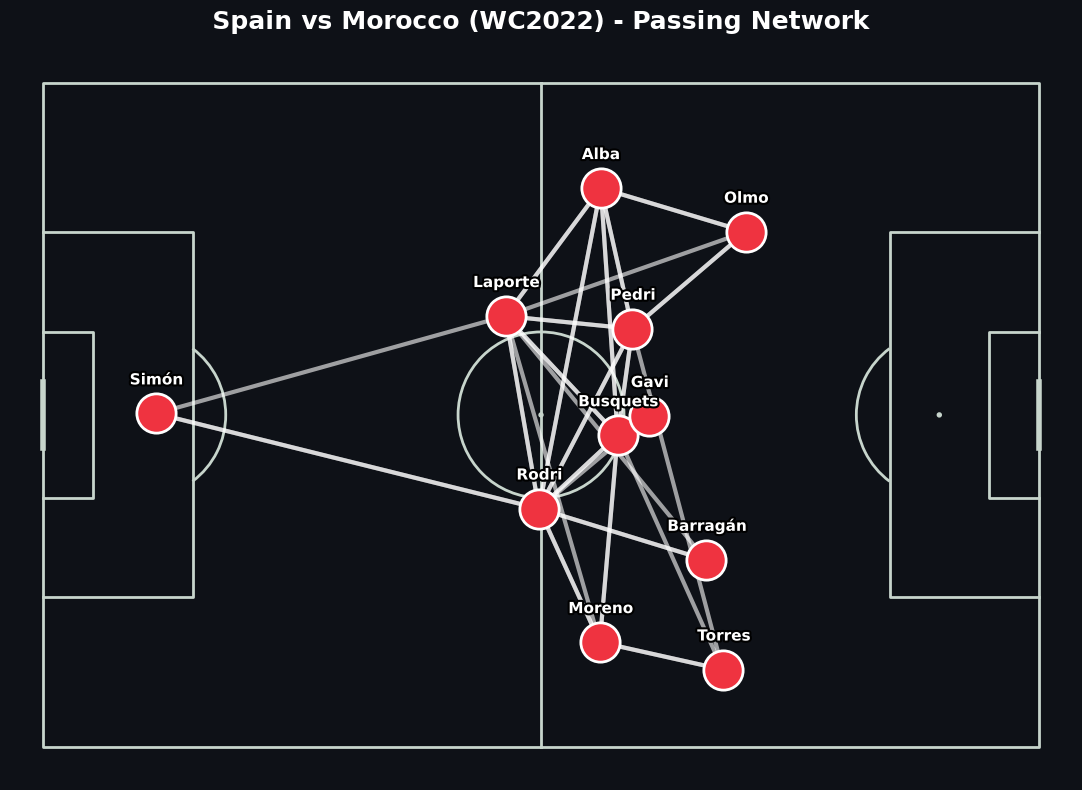

In [5]:
# Pass network for Morocco match specifically
morocco = spain_22[spain_22['opponent']=='Morocco']
draw_pass_network(morocco, 'Spain vs Morocco (WC2022) - Passing Network', 'viz03_pass_network_morocco.png')

---
## GROUP C: Progression (Passing & Carrying)
**Question:** How did Spain move the ball into the final third?

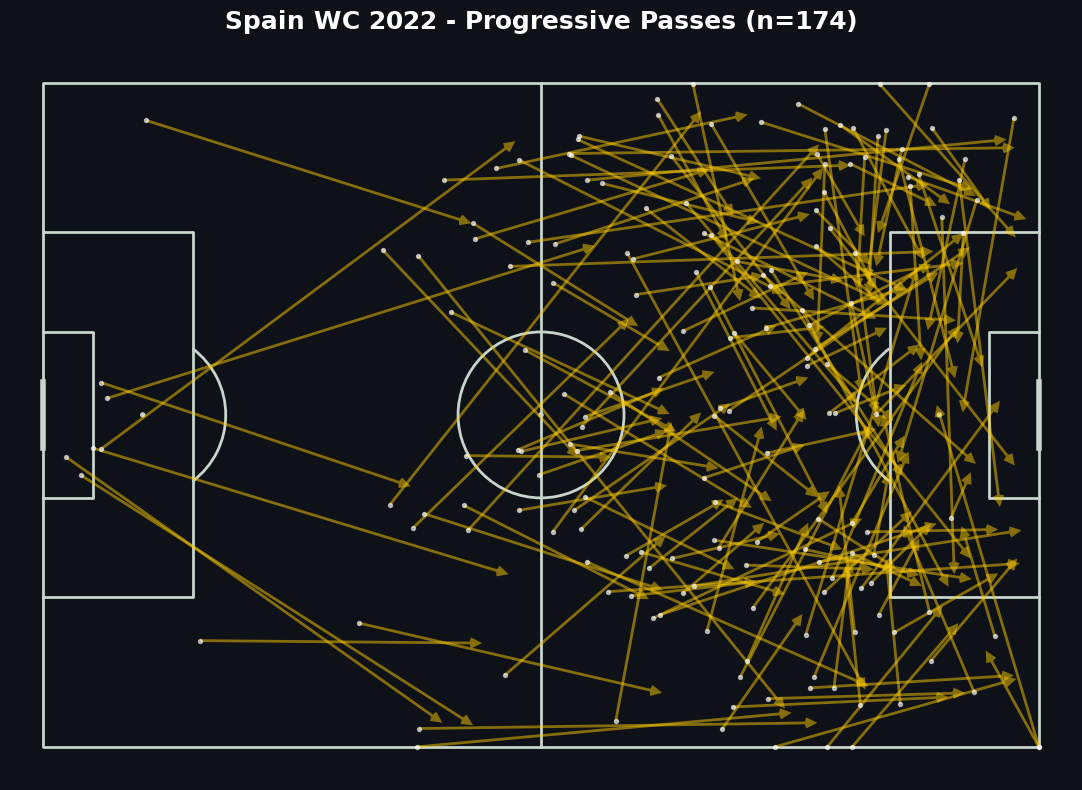

In [6]:
# === VIZ 4: Progressive Pass Map ===
prog = spain_22[spain_22['is_progressive_pass']==True].dropna(subset=['x','y','pass_end_x','pass_end_y'])

pitch = Pitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12,8))
fig.set_facecolor('#0e1117')

pitch.arrows(prog['x'], prog['y'], prog['pass_end_x'], prog['pass_end_y'],
             width=2, headwidth=4, headlength=4, color='#fcca03', ax=ax, alpha=0.5, zorder=1)
pitch.scatter(prog['x'], prog['y'], color='white', s=8, ax=ax, zorder=2, alpha=0.6)

ax.set_title(f'Spain WC 2022 - Progressive Passes (n={len(prog)})', color='white', fontsize=18, fontweight='bold', pad=15)
plt.savefig('../outputs/figures/2022/viz04_progressive_passes.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## GROUP D: Chance Creation
**Question:** When Spain reached the final third, what did they actually create?

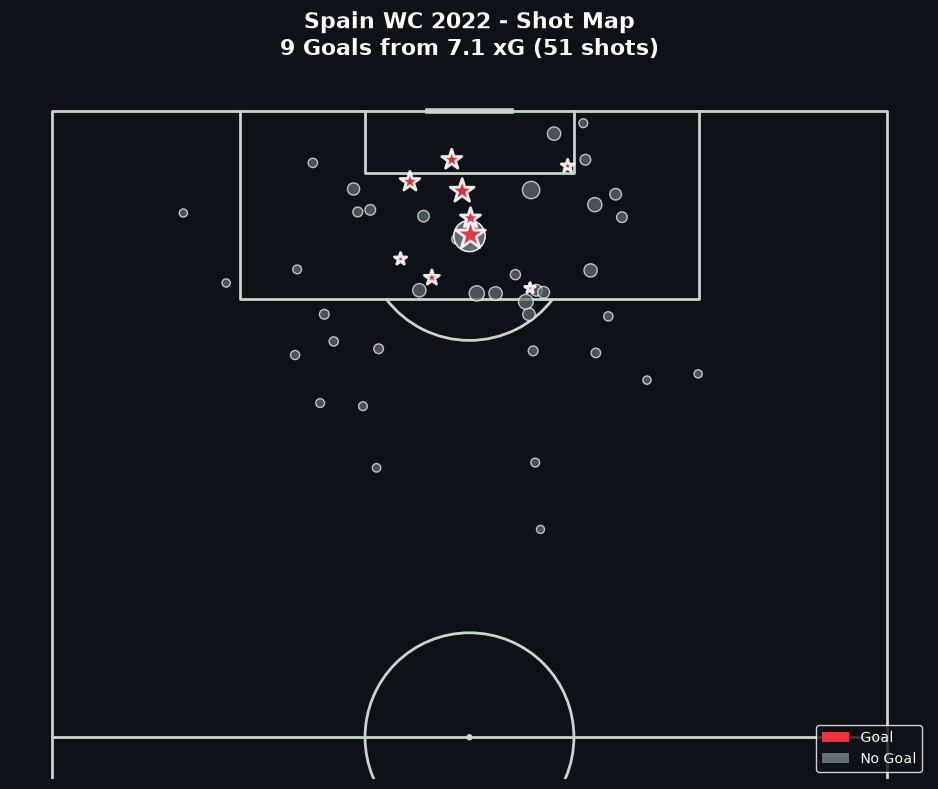

In [7]:
# === VIZ 7: Shot Map with xG ===
shots = spain_22[spain_22['type']=='Shot'].dropna(subset=['x','y']).copy()

xg_col = 'shot_statsbomb_xg' if 'shot_statsbomb_xg' in shots.columns else None
if xg_col:
    shots['xg'] = pd.to_numeric(shots[xg_col], errors='coerce').fillna(0)
else:
    shots['xg'] = 0.1 

shots['is_goal'] = shots['shot_outcome'].str.lower().str.contains('goal', na=False)

pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0e1117', line_color='#c7d5cc', half=True)
fig, ax = pitch.draw(figsize=(10,8))
fig.set_facecolor('#0e1117')

ng = shots[~shots['is_goal']]
pitch.scatter(ng['x'], ng['y'], s=ng['xg']*600+30, color='#636e72', edgecolors='white',
              lw=1, ax=ax, alpha=0.7, zorder=2)

g = shots[shots['is_goal']]
if len(g)>0:
    pitch.scatter(g['x'], g['y'], s=g['xg']*600+30, color='#ef3340', edgecolors='white',
                  lw=2, ax=ax, alpha=0.9, zorder=3, marker='*')

total_xg = shots['xg'].sum()
total_goals = shots['is_goal'].sum()
ax.set_title(f'Spain WC 2022 - Shot Map\n{total_goals} Goals from {total_xg:.1f} xG ({len(shots)} shots)',
             color='white', fontsize=16, fontweight='bold', pad=10)

leg_elements = [mpatches.Patch(facecolor='#ef3340', label='Goal'),
                mpatches.Patch(facecolor='#636e72', label='No Goal')]
ax.legend(handles=leg_elements, loc='lower right', fontsize=10, facecolor='#0e1117',
          edgecolor='white', labelcolor='white')

plt.savefig('../outputs/figures/2022/viz07_shot_map.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## EXPLICIT STAT SCORECARD

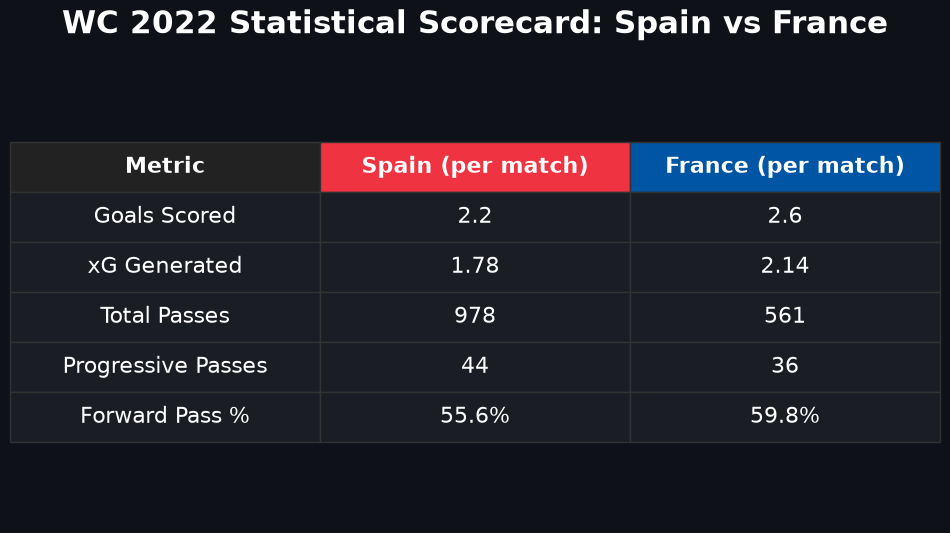

In [8]:
# === VIZ 9: VISUAL STAT SCORECARD ===
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0e1117')
ax.axis('off')

spain_passes = len(spain_22[spain_22['type']=='Pass'])
spain_goals = int(spain_22[spain_22['shot_outcome'].str.lower().str.contains('goal', na=False) == True].shape[0])
spain_xg = pd.to_numeric(spain_22['shot_statsbomb_xg'], errors='coerce').sum()
spain_prog = len(spain_22[spain_22['is_progressive_pass']==True])
spain_fwd_ratio = spain_22[spain_22['type']=='Pass']['is_forward_pass'].mean() * 100
spain_matches = spain_22['match_id'].nunique()

france_passes = len(france_22[france_22['type']=='Pass'])
france_goals = int(france_22[france_22['shot_outcome'].str.lower().str.contains('goal', na=False) == True].shape[0])
france_xg = pd.to_numeric(france_22['shot_statsbomb_xg'], errors='coerce').sum()
france_prog = len(france_22[france_22['is_progressive_pass']==True])
france_fwd_ratio = france_22[france_22['type']=='Pass']['is_forward_pass'].mean() * 100
france_matches = france_22['match_id'].nunique()

table_data = [
    ['Metric', 'Spain (per match)', 'France (per match)'],
    ['Goals Scored', f'{spain_goals/spain_matches:.1f}', f'{france_goals/france_matches:.1f}'],
    ['xG Generated', f'{spain_xg/spain_matches:.2f}', f'{france_xg/france_matches:.2f}'],
    ['Total Passes', f'{spain_passes/spain_matches:.0f}', f'{france_passes/france_matches:.0f}'],
    ['Progressive Passes', f'{spain_prog/spain_matches:.0f}', f'{france_prog/france_matches:.0f}'],
    ['Forward Pass %', f'{spain_fwd_ratio:.1f}%', f'{france_fwd_ratio:.1f}%']
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center')
table.scale(1, 3)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#333333')
    if row == 0:
        cell.set_facecolor('#ef3340' if col == 1 else '#0055A4' if col == 2 else '#222222')
        cell.get_text().set_color('white')
        cell.get_text().set_fontweight('bold')
    else:
        cell.set_facecolor('#1a1d24')
        cell.get_text().set_color('white')
    cell.get_text().set_fontsize(16)

plt.title('WC 2022 Statistical Scorecard: Spain vs France', color='white', fontsize=22, fontweight='bold', pad=20)
plt.savefig('../outputs/figures/2022/viz09_scorecard.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('\n' + '='*80)